<a href="https://colab.research.google.com/github/kayorde25/Satellite-image-classification-and-clustering/blob/main/satellite_image_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Satellite Image Embedding + Clustering

## Project Overview
This project explores how pretrained computer vision models can be used to:
- Extract **embeddings** from satellite images
- Perform **unsupervised clustering**
- Discover **land-use patterns** without labels

## Objectives
- Convert satellite images into feature vectors (embeddings)
- Reduce dimensionality for analysis
- Cluster images using unsupervised learning
- Evaluate clustering performance
- Visualize embedding space

## Dataset
We use the **EuroSAT dataset**, derived from Sentinel-2 satellite imagery:
- ~27,000 images
- 10 land-use classes (forest, residential, river, etc.)

## Methods
- Pretrained CNN: ResNet50
- Feature extraction (no classifier)
- PCA for dimensionality reduction
- KMeans / HDBSCAN clustering
- UMAP for visualization

In [20]:
!pip install -q torch torchvision scikit-learn umap-learn matplotlib pandas numpy hdbscan

## Step 1: Import Libraries

We import all required libraries for:
- Deep learning (PyTorch)
- Data processing (NumPy, Pandas)
- Clustering and evaluation (scikit-learn)
- Visualization (Matplotlib, UMAP)

In [21]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import umap
import warnings
warnings.filterwarnings("ignore")

## Step 2: Check Hardware (GPU/CPU)

Using a GPU speeds up embedding extraction significantly.

In [22]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


## Step 3: Load and Transform Dataset

- Resize images to 224×224 (required for ResNet)
- Convert images to tensors

In [23]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.EuroSAT(
    root="/content/data",
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=32, shuffle=False)

print("Dataset size:", len(dataset))
print("Classes:", dataset.classes)

Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Step 4: Visualize Sample Images

Before modeling, we inspect the dataset to understand its structure.

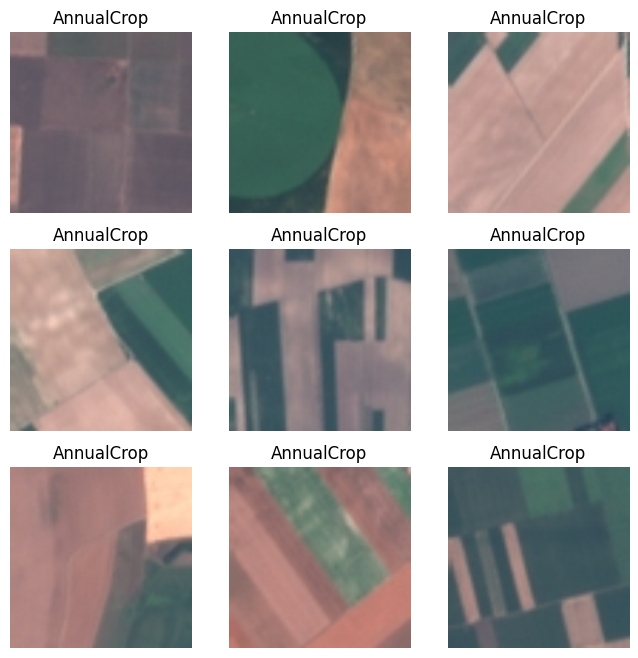

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes = axes.ravel()

for i in range(9):
    img, label = dataset[i]
    img = img.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(dataset.classes[label])
    axes[i].axis("off")

plt.show()

## Step 5: Load Pretrained Model

Use **ResNet50 pretrained on ImageNet**.

Key idea:
- Remove final classification layer
- Use model as a **feature extractor**

In [25]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = nn.Identity()
model = model.to(device)
model.eval()

print("Model ready")

Model ready


## Step 6: Extract Embeddings

Each image is converted into a **2048-dimensional vector**.

In [26]:
embeddings = []
labels = []

with torch.no_grad():
    for images, y in loader:
        images = images.to(device)
        feats = model(images)

        embeddings.append(feats.cpu().numpy())
        labels.append(y.numpy())

X = np.vstack(embeddings)
y = np.hstack(labels)

print("Embeddings shape:", X.shape)

Embeddings shape: (27000, 2048)


## Step 7: Standardize + Reduce Dimensions

- Standardize features
- Apply PCA (reduce 2048 → 50 dimensions)

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)

Reduced shape: (27000, 50)


## Step 8: Clustering (KMeans)

We cluster embeddings into 10 groups.

In [28]:
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

print("Clusters:", np.unique(clusters))

Clusters: [0 1 2 3 4 5 6 7 8 9]


## Step 9: Evaluate Clustering

We compare clusters with true labels using:
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)

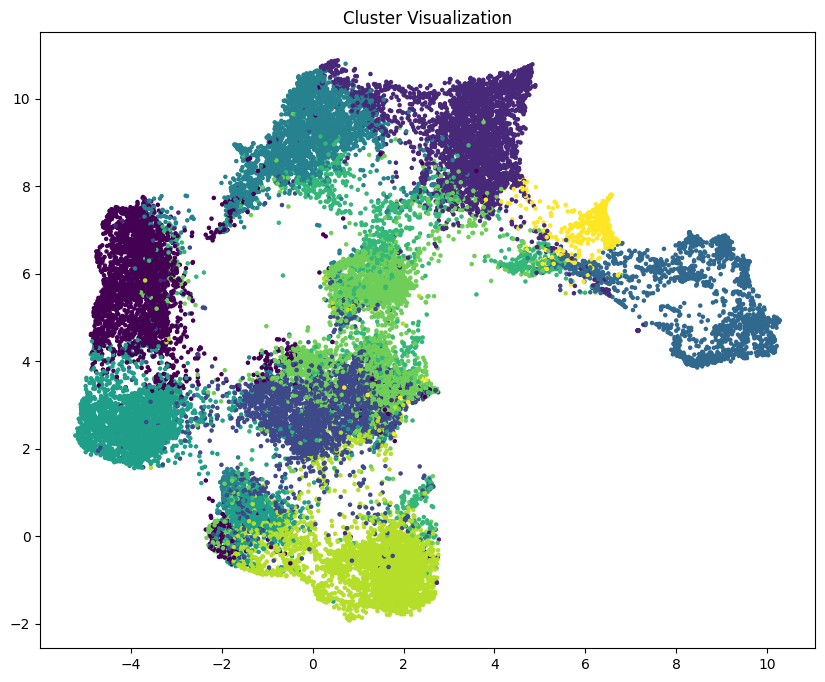

In [16]:
reducer = umap.UMAP()
X_2d = reducer.fit_transform(X_pca)

plt.figure(figsize=(10,8))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, s=5)
plt.title("Cluster Visualization")
plt.show()

## Step 10: UMAP Visualization

We project embeddings into 2D space for visualization.

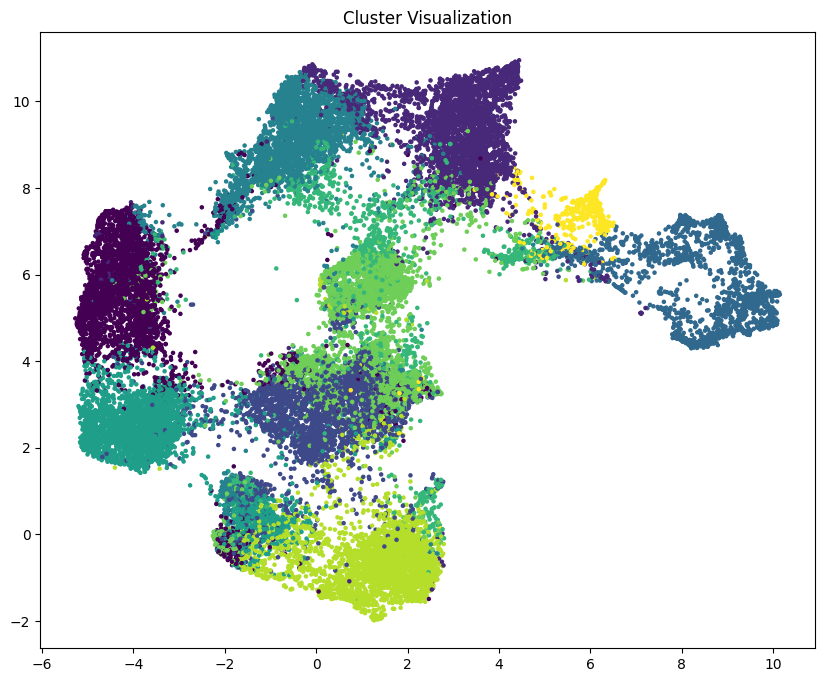

In [17]:
reducer = umap.UMAP()
X_2d = reducer.fit_transform(X_pca)

plt.figure(figsize=(10,8))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, s=5)
plt.title("Cluster Visualization")
plt.show()

## Step 11: Inspect Cluster Samples

We visualize images within each cluster to interpret results.

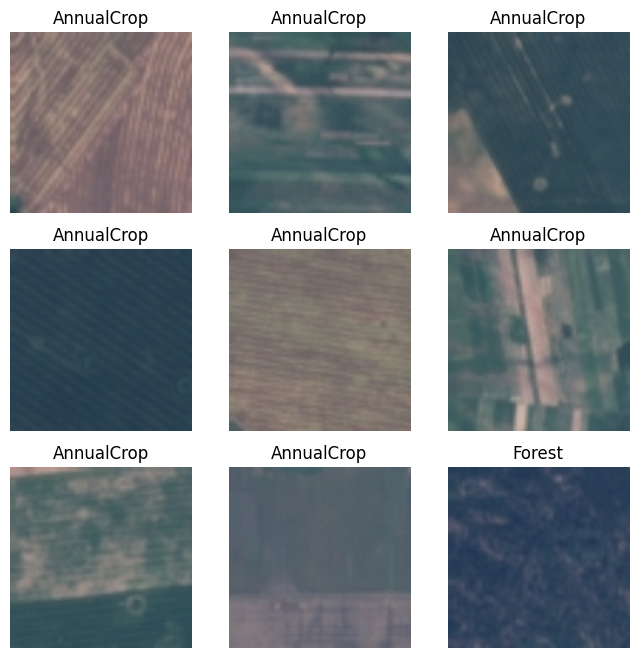

In [18]:
def show_cluster_examples(cluster_id):
    idxs = np.where(clusters == cluster_id)[0][:9]

    fig, axes = plt.subplots(3,3, figsize=(8,8))
    axes = axes.ravel()

    for ax, idx in zip(axes, idxs):
        img, label = dataset[idx]
        img = img.permute(1,2,0).numpy()

        ax.imshow(img)
        ax.set_title(dataset.classes[label])
        ax.axis("off")

    plt.show()

show_cluster_examples(0)

## Step 12: Save Results

We save clustering outputs for analysis.

In [19]:
df = pd.DataFrame({
    "true_label": y,
    "cluster": clusters,
    "x": X_2d[:,0],
    "y": X_2d[:,1]
})

df.to_csv("/content/results.csv", index=False)
print("Saved results")

Saved results


# Conclusion

## Key Takeaways
- Pretrained CNN embeddings capture meaningful patterns in satellite imagery
- Unsupervised clustering can group land-use types effectively
- Visualization reveals separability of classes in embedding space

## Next Steps
- Try different models (EfficientNet, ViT)
- Use HDBSCAN for density-based clustering
- Apply to real geospatial (GeoTIFF) datasets
- Add temporal change detection

## Impact
This project demonstrates:
- Embedding-based ML workflows
- Unsupervised learning
- Model evaluation
- Reproducible data science pipelines